In [2]:
# ==========================================================
# TASK 1: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    confusion_matrix
)

# Load Dataset

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv"

df = pd.read_csv(url, header=None)

# Assign Column Headers

headers = [
    "symboling",
    "normalized-losses",
    "make",
    "fuel-type",
    "aspiration",
    "num-of-doors",
    "body-style",
    "drive-wheels",
    "engine-location",
    "wheel-base",
    "length",
    "width",
    "height",
    "curb-weight",
    "engine-type",
    "num-of-cylinders",
    "engine-size",
    "fuel-system",
    "bore",
    "stroke",
    "compression-ratio",
    "horsepower",
    "peak-rpm",
    "city-mpg",
    "highway-mpg",
    "price"
]

df.columns = headers

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nFirst 10 Rows:")
display(df.head(10))

Dataset Shape:
(205, 26)

First 10 Rows:


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


In [4]:
df.replace("?", np.nan, inplace=True)

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64


In [5]:
numeric_columns = [
    'normalized-losses',
    'bore',
    'stroke',
    'horsepower',
    'peak-rpm',
    'price'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

symboling              int64
normalized-losses    float64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object


In [6]:
# ==========================================================
# Missing Value Treatment
# Mean Replacement + Mode Replacement
# ==========================================================

# Mean replacement for numerical columns
mean_columns = [
    'normalized-losses',
    'bore',
    'stroke',
    'horsepower',
    'peak-rpm'
]

for col in mean_columns:
    df[col] = df[col].fillna(df[col].mean())

# Mode replacement for categorical column
df['num-of-doors'] = df['num-of-doors'].fillna(
    df['num-of-doors'].mode()[0]
)

# Verify missing values after treatment
print("Missing Values After Treatment:")
print(df.isnull().sum())

Missing Values After Treatment:
symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                4
dtype: int64


In [7]:
df.dropna(subset=['price'], inplace=True)

print(df.shape)

(201, 26)


In [8]:
print("Mean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nStandard Deviation")
print(df.std(numeric_only=True))

Mean
symboling                0.840796
normalized-losses      122.000000
wheel-base              98.797015
length                 174.200995
width                   65.889055
height                  53.766667
curb-weight           2555.666667
engine-size            126.875622
bore                     3.330692
stroke                   3.256874
compression-ratio       10.164279
horsepower             103.405534
peak-rpm              5117.665368
city-mpg                25.179104
highway-mpg             30.686567
price                13207.129353
dtype: float64

Median
symboling                1.000000
normalized-losses      122.000000
wheel-base              97.000000
length                 173.200000
width                   65.500000
height                  54.100000
curb-weight           2414.000000
engine-size            120.000000
bore                     3.310000
stroke                   3.290000
compression-ratio        9.000000
horsepower              95.000000
peak-rpm            

In [9]:
print(df.dtypes)

symboling              int64
normalized-losses    float64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object


In [10]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print("\n================================")
    print(col)
    print(df[col].unique())


make
['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']

fuel-type
['gas' 'diesel']

aspiration
['std' 'turbo']

num-of-doors
['two' 'four']

body-style
['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']

drive-wheels
['rwd' 'fwd' '4wd']

engine-location
['front' 'rear']

engine-type
['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf']

num-of-cylinders
['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']

fuel-system
['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']


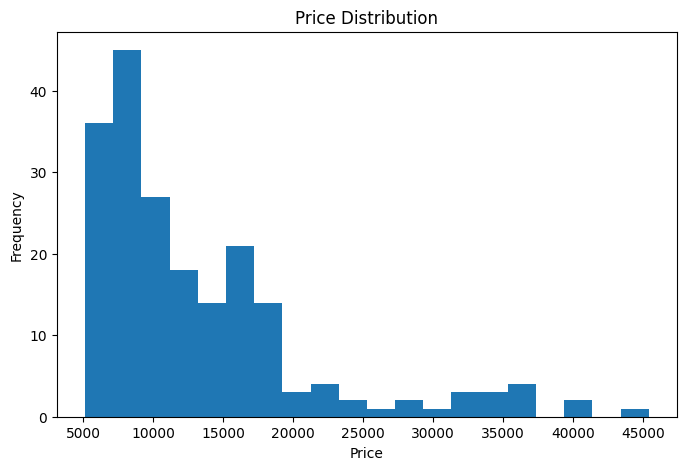

In [11]:
plt.figure(figsize=(8,5))

plt.hist(df['price'], bins=20)

plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

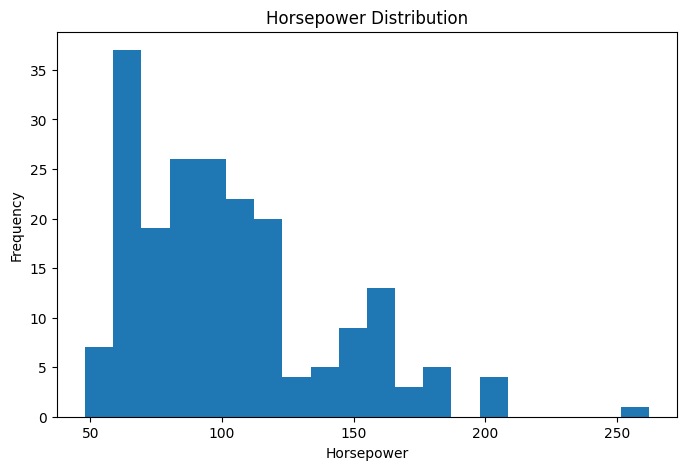

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df['horsepower'], bins=20)

plt.title('Horsepower Distribution')
plt.xlabel('Horsepower')
plt.ylabel('Frequency')

plt.show()

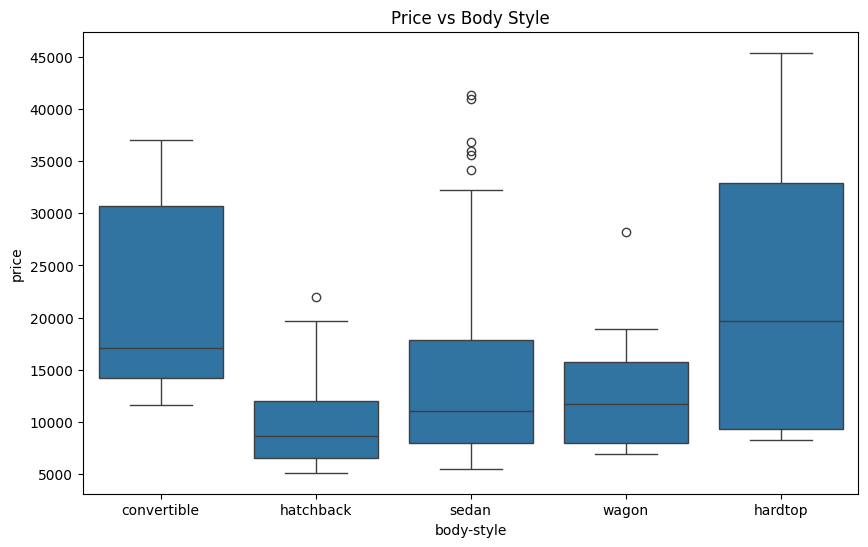

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='body-style',
    y='price',
    data=df
)

plt.title('Price vs Body Style')

plt.show()

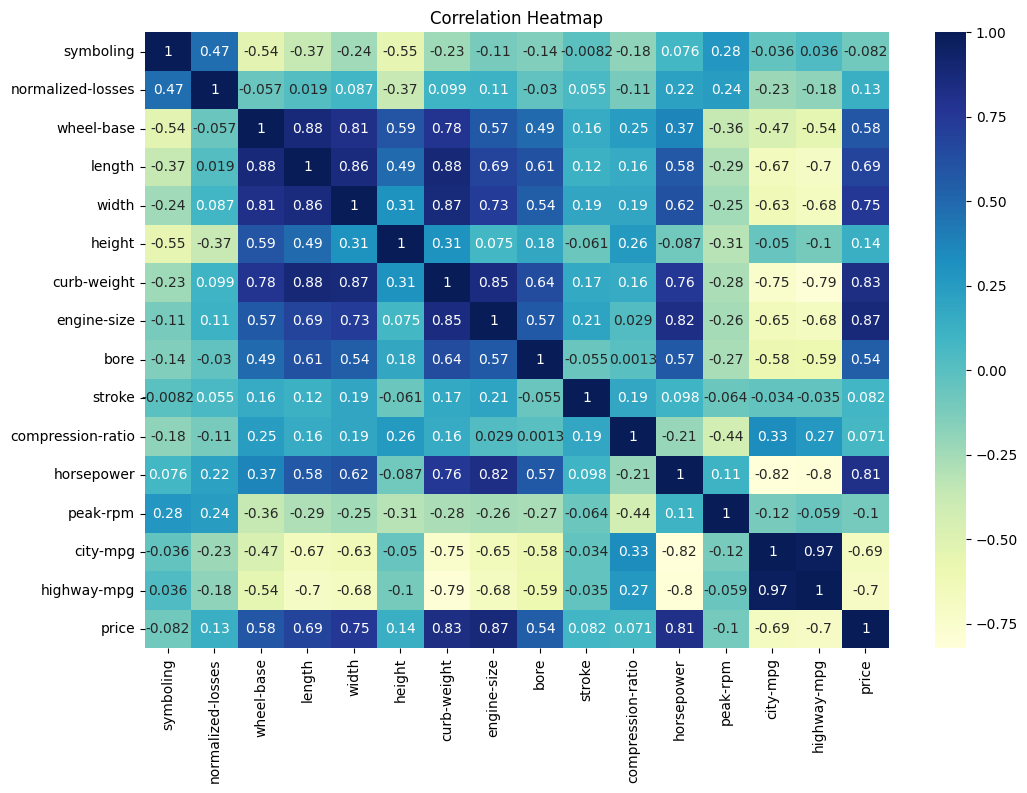

In [17]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='YlGnBu'
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
df['city-L/100km'] = 235 / df['city-mpg']

display(df[['city-mpg','city-L/100km']].head())

,city-mpg,city-L/100km
0,21,11.190476
1,21,11.190476
2,19,12.368421
3,24,9.791667
4,18,13.055556


In [ ]:
bins = np.linspace(
    df['horsepower'].min(),
    df['horsepower'].max(),
    4
)

labels = ['Low','Medium','High']

df['horsepower-binned'] = pd.cut(
    df['horsepower'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(df['horsepower-binned'].value_counts())

horsepower-binned
Low       153
Medium     43
High        5
Name: count, dtype: int64


In [ ]:
df['horsepower-normalized'] = (
    (df['horsepower'] - df['horsepower'].min())
    /
    (df['horsepower'].max() - df['horsepower'].min())
)

display(
    df[['horsepower',
        'horsepower-normalized']].head()
)

,horsepower,horsepower-normalized
0,111.0,0.294393
1,111.0,0.294393
2,154.0,0.495327
3,102.0,0.252336
4,115.0,0.313084


In [ ]:
X = df[['horsepower','engine-size']]

y = df['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [ ]:
print("LINEAR REGRESSION RESULTS")

print("R2 Score:")
print(r2_score(y_test, y_pred))

print("\nMAE:")
print(mean_absolute_error(y_test, y_pred))

print("\nMSE:")
print(mean_squared_error(y_test, y_pred))

LINEAR REGRESSION RESULTS
R2 Score:
0.7555654387380517

MAE:
3997.0418248986043

MSE:
29905779.8002822


In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
print("RANDOM FOREST RESULTS")

print("R2 Score:")
print(r2_score(y_test, rf_pred))

print("\nMAE:")
print(mean_absolute_error(y_test, rf_pred))

print("\nMSE:")
print(mean_squared_error(y_test, rf_pred))

RANDOM FOREST RESULTS
R2 Score:
0.9268293080707919

MAE:
2153.8512526504664

MSE:
8952198.041766157


In [ ]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

lr2 = LinearRegression()

lr2.fit(X_train2, y_train2)

pred2 = lr2.predict(X_test2)

print("70/30 SPLIT")

print("R2:")
print(r2_score(y_test2, pred2))

print("MAE:")
print(mean_absolute_error(y_test2, pred2))

print("MSE:")
print(mean_squared_error(y_test2, pred2))

70/30 SPLIT
R2:
0.7642207925811224
MAE:
3359.3279608911475
MSE:
22349902.04828839


In [ ]:
df['price-category'] = pd.qcut(
    df['price'],
    3,
    labels=['Low','Medium','High']
)

print(df['price-category'].value_counts())

price-category
Low       67
Medium    67
High      67
Name: count, dtype: int64


In [ ]:
X_cls = df[['horsepower','engine-size']]

y_cls = df['price-category']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42
)

In [ ]:
log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train_c,
    y_train_c
)

pred_cls = log_model.predict(
    X_test_c
)

In [ ]:
print("Accuracy")

print(
    accuracy_score(
        y_test_c,
        pred_cls
    )
)

Accuracy
0.7073170731707317


In [ ]:
cm = confusion_matrix(
    y_test_c,
    pred_cls
)

print(cm)

[[12  0  2]
 [ 0 11  3]
 [ 4  3  6]]


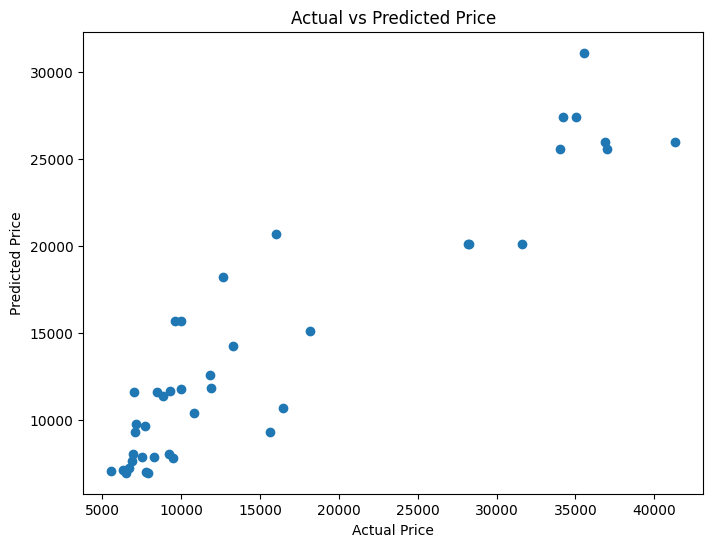

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()